# PRT564 Data Analytics and Visualisation — Assessment 2
## Predictive Modelling and Demand Analysis for NSW Opal Trip Data

**Group Members:**
- Nasla Maharjan (S398425)
- Krish Rajbhandari (S395754)
- Suyog Kadariya (S393829)

**Campus:** Sydney | **Unit:** PRT564

**Data Sources:**
- Opal Trip Counts (NRT) — data.gov.au
- NSW Population Data — Australian Bureau of Statistics (ABS 3101051)

**GitHub:** *(add your GitHub link here before submission)*

---
### Notebook Structure
1. Setup & Library Imports
2. Data Loading (Opal + ABS Population)
3. Data Cleaning & Integration (ETL)
4. Feature Engineering
5. Exploratory Data Analysis (EDA)
6. Regression Modelling (M1, M2, M3)
7. Statistical Testing
8. Model Comparison & Evaluation
9. Key Findings & Interpretation
10. Limitations & Recommendations
11. Save Outputs

---
## 1. Setup & Library Imports

In [1]:
pip install scipy openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── LIBRARY IMPORTS ───────────────────────────────────────────────────────────
# Standard data science libraries used throughout this analysis.
# Authored by: Nasla Maharjan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
from scipy.stats import shapiro, wilcoxon

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Data Loading
**Heterogeneous data integration:** Two separate data sources are loaded:
- **Opal trips CSV** — transport tap-on/tap-off counts from data.gov.au
- **ABS population Excel** — NSW population statistics from the Australian Bureau of Statistics

Combining these two sources allows us to normalise demand by population, which is essential
for understanding whether trip growth reflects genuine behavioural change or simply more residents.

In [3]:
# ── LOAD OPAL TRIP DATA ───────────────────────────────────────────────────────
# Source: data.gov.au — 'Opal Trip Counts Based on NRT – by month'
# Contains monthly tap-on records by travel mode and card type
# Authored by: Nasla Maharjan

opal_raw = pd.read_csv('opal_trips.csv')
print(f"Opal data loaded: {opal_raw.shape[0]} records, {opal_raw.shape[1]} columns")
print(f"Date range: {opal_raw['Year_Month'].min()} to {opal_raw['Year_Month'].max()}")
print(f"Unique travel modes: {opal_raw['Travel_Mode'].unique()}")
print(f"\nFirst few rows:")
opal_raw.head(10)

Opal data loaded: 6717 records, 4 columns
Date range: Apr-2017 to Sep-2025
Unique travel modes: <StringArray>
[        'Bus',       'Ferry',  'Light Rail',       'Train',       'Metro',
         'bus',       'ferry',  'light rail',       'metro',       'train',
 'unallocated']
Length: 11, dtype: str

First few rows:


,Year_Month,Card_type,Travel_Mode,Trip
0,Jul-2016,Adult,Bus,13146432.0
1,Jul-2016,Child/Youth,Bus,1079640.0
2,Jul-2016,Concession,Bus,1845322.0
3,Jul-2016,Employee,Bus,64989.0
4,Jul-2016,Free Travel,Bus,25228.0
5,Jul-2016,School Student,Bus,1297240.0
6,Jul-2016,Senior/Pensioner,Bus,3739658.0
7,Jul-2016,Adult,Ferry,861272.0
8,Jul-2016,Child/Youth,Ferry,108450.0
9,Jul-2016,Concession,Ferry,71362.0


In [4]:
# ── LOAD ABS POPULATION DATA ──────────────────────────────────────────────────
# Source: Australian Bureau of Statistics — National, State and Territory Population
# File: 3101051.xlsx, Sheets: Data1 (males by age), Data2 (females by age)
# We sum all age groups across both sexes to get total NSW population per year.
# Authored by: Nasla Maharjan

print("Loading ABS population data...")
data1 = pd.read_excel('3101051.xlsx', sheet_name='Data1', header=None)
data2 = pd.read_excel('3101051.xlsx', sheet_name='Data2', header=None)

print(f"  Data1 shape (male age groups): {data1.shape}")
print(f"  Data2 shape (female age groups): {data2.shape}")

Loading ABS population data...
  Data1 shape (male age groups): (65, 251)
  Data2 shape (female age groups): (65, 54)


---
## 3. Data Cleaning & Integration (ETL Pipeline)
**ETL Steps:**
1. Standardise travel mode category names (remove whitespace, normalise casing)
2. Parse Year_Month string into proper datetime
3. Aggregate trip counts by month and mode (sum across card types)
4. Pivot to wide format (one column per mode)
5. Extract and sum ABS population data
6. Merge Opal and population datasets on year

In [5]:
# ── STEP 1: STANDARDISE TRAVEL MODE NAMES ────────────────────────────────────
# Raw data contains inconsistent casing (e.g. 'train' vs 'Train').
# We apply strip + title case to ensure accurate groupby aggregation.
# Authored by: Nasla Maharjan

opal_raw['Travel_Mode'] = opal_raw['Travel_Mode'].str.strip().str.title()
print(f"Standardised modes: {sorted(opal_raw['Travel_Mode'].unique())}")

Standardised modes: ['Bus', 'Ferry', 'Light Rail', 'Metro', 'Train', 'Unallocated']


In [6]:
# ── STEP 2: PARSE DATES ───────────────────────────────────────────────────────
# Convert 'Jul-2016' string format to proper datetime for time-series analysis.
# Authored by: Nasla Maharjan

opal_raw['Date'] = pd.to_datetime(opal_raw['Year_Month'], format='%b-%Y')
print("Date column created successfully.")
opal_raw.head()

Date column created successfully.


,Year_Month,Card_type,Travel_Mode,Trip,Date
0,Jul-2016,Adult,Bus,13146432.0,2016-07-01
1,Jul-2016,Child/Youth,Bus,1079640.0,2016-07-01
2,Jul-2016,Concession,Bus,1845322.0,2016-07-01
3,Jul-2016,Employee,Bus,64989.0,2016-07-01
4,Jul-2016,Free Travel,Bus,25228.0,2016-07-01


In [7]:
# ── STEP 3 & 4: AGGREGATE AND PIVOT ──────────────────────────────────────────
# Sum trip counts across all card types (Adult, Concession, etc.) per month per mode.
# Then pivot so each transport mode becomes its own column.
# This gives us a clean monthly time-series per mode.
# Authored by: Nasla Maharjan

opal_monthly = opal_raw.groupby(['Date', 'Travel_Mode'])['Trip'].sum().reset_index()
opal_monthly = opal_monthly.sort_values('Date').reset_index(drop=True)

print(f"Aggregated to {len(opal_monthly)} month-mode combinations")
print(f"Modes after standardisation: {sorted(opal_monthly['Travel_Mode'].unique())}")

# Pivot to wide format
opal_pivot = opal_monthly.pivot(index='Date', columns='Travel_Mode', values='Trip').fillna(0)
opal_pivot['Total_Trips'] = opal_pivot.sum(axis=1)
opal_pivot = opal_pivot.reset_index().sort_values('Date')

print(f"\nPivoted shape: {opal_pivot.shape}")
print(f"Columns: {list(opal_pivot.columns)}")
opal_pivot.head()

Aggregated to 560 month-mode combinations
Modes after standardisation: ['Bus', 'Ferry', 'Light Rail', 'Metro', 'Train', 'Unallocated']

Pivoted shape: (117, 8)
Columns: ['Date', 'Bus', 'Ferry', 'Light Rail', 'Metro', 'Train', 'Unallocated', 'Total_Trips']


Travel_Mode,Date,Bus,Ferry,Light Rail,Metro,Train,Unallocated,Total_Trips
0,2016-07-01,21198509.0,1213712.0,827732.0,0.0,28819249.0,0.0,52059202.0
1,2016-08-01,25210772.0,1095055.0,840800.0,0.0,32393980.0,0.0,59540607.0
2,2016-09-01,23011540.0,1143718.0,758073.0,0.0,30648352.0,0.0,55561683.0
3,2016-10-01,23095302.0,1281152.0,776960.0,0.0,30106833.0,0.0,55260247.0
4,2016-11-01,24422383.0,1302501.0,705265.0,0.0,31318279.0,0.0,57748428.0


In [8]:
# ── STEP 5: EXTRACT ABS POPULATION ───────────────────────────────────────────
# ABS Excel file has data starting at row 10 (0-indexed).
# Column 0 = date, remaining columns = age group counts.
# We sum all age groups for males and females to get total NSW population.
# Authored by: Nasla Maharjan

print("Processing ABS population data...")

dates      = pd.to_datetime(data1.iloc[10:, 0].reset_index(drop=True))
male_data  = data1.iloc[10:, 1:].apply(pd.to_numeric, errors='coerce').sum(axis=1)
female_data = data2.iloc[10:, 1:].apply(pd.to_numeric, errors='coerce').sum(axis=1)
pop_total  = male_data + female_data

population_data = pd.DataFrame({
    'Date': dates,
    'Total_Population': pop_total
}).sort_values('Date').reset_index(drop=True)

print(f"Population records: {len(population_data)}")
print(f"Date range: {population_data['Date'].min()} to {population_data['Date'].max()}")
print(f"Population range: {population_data['Total_Population'].min():,.0f} to {population_data['Total_Population'].max():,.0f}")
population_data.head(10)

Processing ABS population data...
Population records: 65
Date range: 1971-06-01 00:00:00 to 2025-06-01 00:00:00
Population range: 9,451,006 to 17,185,048


,Date,Total_Population
0,1971-06-01,NaN
1,1972-06-01,NaN
2,1973-06-01,NaN
3,1974-06-01,NaN
4,1975-06-01,NaN
5,1976-06-01,NaN
6,1977-06-01,NaN
7,1978-06-01,NaN
8,1979-06-01,NaN
9,1980-06-01,NaN


In [9]:
# ── STEP 6: MERGE OPAL + POPULATION ──────────────────────────────────────────
# Population data is annual; Opal data is monthly.
# We merge on year (left join) so each monthly Opal row gets its annual population value.
# Limitation: assumes population is stable within each year (annual interpolation).
# Authored by: Nasla Maharjan

print("Merging Opal and population datasets...")

opal_pivot['Year']       = opal_pivot['Date'].dt.year
population_data['Year']  = population_data['Date'].dt.year
pop_by_year              = population_data[['Year', 'Total_Population']].drop_duplicates()

merged       = opal_pivot.merge(pop_by_year, on='Year', how='left')
merged       = merged.sort_values('Date').reset_index(drop=True)
merged_clean = merged[merged['Total_Population'].notna()].copy()

print(f"Merged dataset: {merged_clean.shape[0]} months")
print(f"Date range: {merged_clean['Date'].min().date()} to {merged_clean['Date'].max().date()}")
print(f"Time span: {(merged_clean['Date'].max() - merged_clean['Date'].min()).days/365:.1f} years")
print(f"Missing values: {merged_clean.isnull().sum().sum()}")
merged_clean.head()

Merging Opal and population datasets...
Merged dataset: 114 months
Date range: 2016-07-01 to 2025-12-01
Time span: 9.4 years
Missing values: 0


,Date,Bus,Ferry,Light Rail,Metro,Train,Unallocated,Total_Trips,Year,Total_Population
0,2016-07-01,21198509.0,1213712.0,827732.0,0.0,28819249.0,0.0,52059202.0,2016,13485380.0
1,2016-08-01,25210772.0,1095055.0,840800.0,0.0,32393980.0,0.0,59540607.0,2016,13485380.0
2,2016-09-01,23011540.0,1143718.0,758073.0,0.0,30648352.0,0.0,55561683.0,2016,13485380.0
3,2016-10-01,23095302.0,1281152.0,776960.0,0.0,30106833.0,0.0,55260247.0,2016,13485380.0
4,2016-11-01,24422383.0,1302501.0,705265.0,0.0,31318279.0,0.0,57748428.0,2016,13485380.0


---
## 4. Feature Engineering
We create derived features that are essential for regression modelling and EDA.
Each feature is justified below with its purpose.

In [10]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
# Authored by: Nasla Maharjan & Krish Rajbhandari
#
# Feature justifications:
#   Per_Capita_Trips       — normalises demand by population for fair comparison over time
#   Log_Total_Trips        — log transform for log-log regression (elasticity modelling)
#   Log_Population         — log transform for log-log regression
#   Population_YoY_Growth  — annual growth rate; key independent variable in regression
#   Trips_YoY_Growth       — annual trip growth; used for EDA comparison charts
#   Time_Index             — linear trend variable; captures infrastructure growth over time
#   Month, Quarter, Season — temporal dummies; capture seasonality in demand
#   Mode_Proportion        — mode share %; shows how travel mix changes over time
#   COVID_Flag             — binary dummy for COVID period (Mar 2020 – Dec 2021)
#   Post_COVID_Recovery    — binary dummy for post-COVID period (Jan 2022 onwards)
#                            Separates three structural demand regimes in the data

print("Creating derived features...")

# Per-capita demand (trips per 1000 residents)
merged_clean['Per_Capita_Trips'] = merged_clean['Total_Trips'] / merged_clean['Total_Population'] * 1000

# Year-over-year growth rates (12-month lag)
merged_clean['Population_YoY_Growth'] = merged_clean['Total_Population'].pct_change(12) * 100
merged_clean['Trips_YoY_Growth']      = merged_clean['Total_Trips'].pct_change(12) * 100

# Month-over-month changes
merged_clean['Trips_MoM_Change']     = merged_clean['Total_Trips'].diff()
merged_clean['Trips_MoM_Pct_Change'] = merged_clean['Total_Trips'].pct_change() * 100

# Log transformations for regression (required for log-log elasticity model)
merged_clean['Log_Total_Trips'] = np.log(merged_clean['Total_Trips'])
merged_clean['Log_Population']  = np.log(merged_clean['Total_Population'])

# Mode proportions and per-capita by mode
mode_cols = [c for c in merged_clean.columns if c in ['Bus', 'Train', 'Light Rail', 'Ferry', 'Metro']]
for mode in mode_cols:
    merged_clean[f'{mode}_Proportion'] = (merged_clean[mode] / merged_clean['Total_Trips'] * 100)
    merged_clean[f'{mode}_Per_Capita'] = (merged_clean[mode] / merged_clean['Total_Population'] * 1000)

# Temporal variables
merged_clean['Time_Index'] = range(len(merged_clean))
merged_clean['Month']      = merged_clean['Date'].dt.month
merged_clean['Quarter']    = merged_clean['Date'].dt.quarter
merged_clean['Season']     = merged_clean['Date'].dt.month % 12 // 3 + 1

# COVID structural period flags
# Period 0 — Pre-COVID  (before Mar 2020): baseline demand
# Period 1 — COVID      (Mar 2020 – Dec 2021): demand collapsed ~47%
# Period 2 — Recovery   (Jan 2022 onwards): partial recovery, new lower baseline
merged_clean['COVID_Flag'] = (
    (merged_clean['Date'] >= '2020-03-01') &
    (merged_clean['Date'] <= '2021-12-31')
).astype(int)

merged_clean['Post_COVID_Recovery'] = (
    merged_clean['Date'] > '2021-12-31'
).astype(int)

print(f"Feature engineering complete. Total columns: {merged_clean.shape[1]}")
merged_clean.head()

Creating derived features...
Feature engineering complete. Total columns: 33


,Date,Bus,Ferry,Light Rail,Metro,Train,Unallocated,Total_Trips,Year,Total_Population,...,Metro_Proportion,Metro_Per_Capita,Train_Proportion,Train_Per_Capita,Time_Index,Month,Quarter,Season,COVID_Flag,Post_COVID_Recovery
0,2016-07-01,21198509.0,1213712.0,827732.0,0.0,28819249.0,0.0,52059202.0,2016,13485380.0,...,0.0,0.0,55.358607,2137.073557,0,7,3,3,0,0
1,2016-08-01,25210772.0,1095055.0,840800.0,0.0,32393980.0,0.0,59540607.0,2016,13485380.0,...,0.0,0.0,54.406533,2402.155520,1,8,3,3,0,0
2,2016-09-01,23011540.0,1143718.0,758073.0,0.0,30648352.0,0.0,55561683.0,2016,13485380.0,...,0.0,0.0,55.160950,2272.709557,2,9,3,4,0,0
3,2016-10-01,23095302.0,1281152.0,776960.0,0.0,30106833.0,0.0,55260247.0,2016,13485380.0,...,0.0,0.0,54.481901,2232.553551,3,10,4,4,0,0
4,2016-11-01,24422383.0,1302501.0,705265.0,0.0,31318279.0,0.0,57748428.0,2016,13485380.0,...,0.0,0.0,54.232262,2322.387578,4,11,4,4,0,0


In [11]:
# ── SUMMARY STATISTICS ────────────────────────────────────────────────────────
# Authored by: Suyog Kadariya

print("KEY DESCRIPTIVE STATISTICS:")
print(f"\nTotal Trips (millions):")
print(f"  Min:    {merged_clean['Total_Trips'].min()/1e6:.2f}M")
print(f"  Mean:   {merged_clean['Total_Trips'].mean()/1e6:.2f}M")
print(f"  Max:    {merged_clean['Total_Trips'].max()/1e6:.2f}M")
print(f"  Std:    {merged_clean['Total_Trips'].std()/1e6:.2f}M")

print(f"\nNSW Population:")
print(f"  Min:    {merged_clean['Total_Population'].min():,.0f}")
print(f"  Max:    {merged_clean['Total_Population'].max():,.0f}")
print(f"  Growth: {(merged_clean['Total_Population'].max()-merged_clean['Total_Population'].min())/merged_clean['Total_Population'].min()*100:.1f}% over study period")

# Three-period summary
pre   = merged_clean[(merged_clean['COVID_Flag']==0) & (merged_clean['Post_COVID_Recovery']==0)]
covid = merged_clean[merged_clean['COVID_Flag']==1]
post  = merged_clean[merged_clean['Post_COVID_Recovery']==1]

print(f"\nTHREE STRUCTURAL PERIODS:")
print(f"  Pre-COVID  ({len(pre):2d} months): avg {pre['Total_Trips'].mean()/1e6:.1f}M trips/month")
print(f"  COVID      ({len(covid):2d} months): avg {covid['Total_Trips'].mean()/1e6:.1f}M trips/month")
print(f"  Recovery   ({len(post):2d} months): avg {post['Total_Trips'].mean()/1e6:.1f}M trips/month")

pct_drop    = (pre['Total_Trips'].mean() - covid['Total_Trips'].mean()) / pre['Total_Trips'].mean() * 100
recovery_gap = pre['Total_Trips'].mean() - post['Total_Trips'].mean()
normal_mean = merged_clean.loc[merged_clean['COVID_Flag']==0, 'Total_Trips'].mean() / 1e6
covid_mean  = merged_clean.loc[merged_clean['COVID_Flag']==1, 'Total_Trips'].mean() / 1e6

print(f"\n  COVID demand reduction:    {pct_drop:.1f}%")
print(f"  Recovery gap (still missing): {recovery_gap/1e6:.1f}M trips/month")

# Detailed describe
merged_clean[['Total_Trips','Total_Population','Per_Capita_Trips','Bus','Train']].describe()

KEY DESCRIPTIVE STATISTICS:

Total Trips (millions):
  Min:    9.09M
  Mean:   48.96M
  Max:    68.45M
  Std:    13.58M

NSW Population:
  Min:    13,485,380
  Max:    15,232,336
  Growth: 13.0% over study period

THREE STRUCTURAL PERIODS:
  Pre-COVID  (44 months): avg 59.1M trips/month
  COVID      (22 months): avg 28.5M trips/month
  Recovery   (48 months): avg 49.0M trips/month

  COVID demand reduction:    51.7%
  Recovery gap (still missing): 10.1M trips/month


,Total_Trips,Total_Population,Per_Capita_Trips,Bus,Train
count,1.140000e+02,1.140000e+02,114.000000,1.140000e+02,1.140000e+02
mean,4.895530e+07,1.439965e+07,3410.414122,1.945610e+07,2.479214e+07
std,1.357623e+07,5.253884e+05,980.007866,5.397160e+06,7.746756e+06
min,9.086788e+06,1.348538e+07,629.407183,4.287197e+06,4.245889e+06
25%,4.065517e+07,1.388692e+07,2780.720402,1.627192e+07,2.008029e+07
50%,5.362150e+07,1.443706e+07,3644.453769,2.060724e+07,2.563678e+07
75%,5.818311e+07,1.480806e+07,4118.911383,2.314290e+07,3.096499e+07
max,6.844949e+07,1.523234e+07,4851.989189,2.874222e+07,3.756212e+07


---
## 5. Exploratory Data Analysis (EDA)
Visualisations are designed to directly inform modelling decisions:
- Time-series plots reveal overall trend and COVID structural break
- Per-capita chart exposes the inverse population-demand relationship
- Seasonal heatmap justifies including Month as a regression feature
- Mode share chart shows how Metro entry changed the transport mix
- YoY growth comparison provides visual proof of demand-population decoupling

Trips vs Population correlation: -0.1629
Note: Despite visual similarity, raw correlation is misleading due to COVID.
Per-capita analysis (EDA 3) gives a more accurate picture.


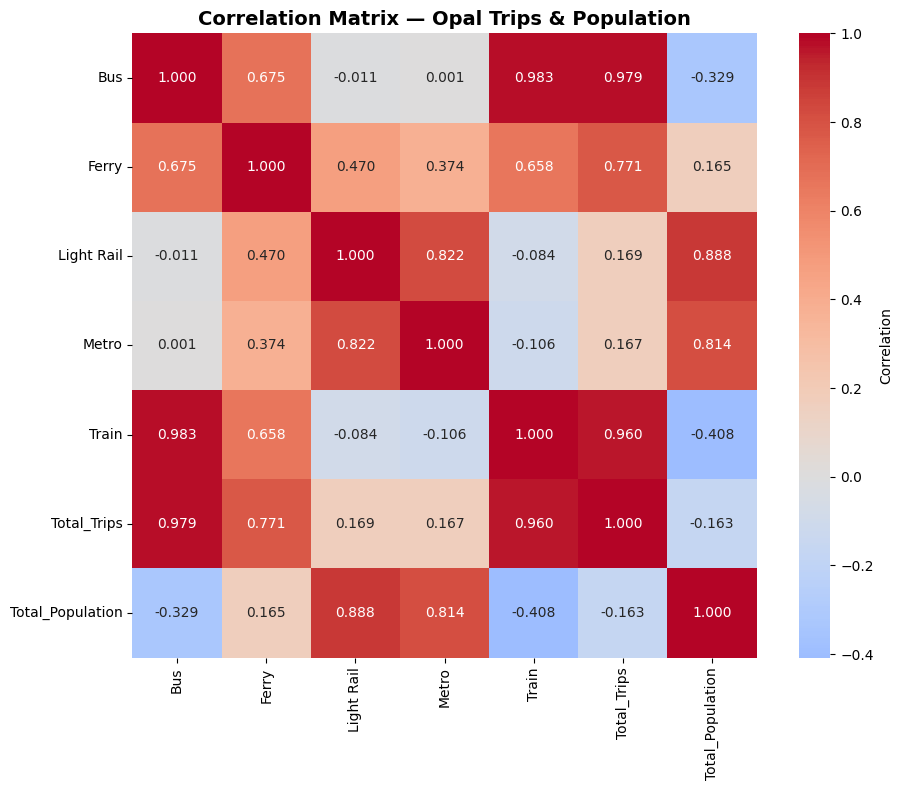

In [12]:
# ── EDA 1: CORRELATION MATRIX ─────────────────────────────────────────────────
# Checks linear relationships between all numeric variables.
# Key interest: correlation between Total_Trips and Total_Population.
# Authored by: Nasla Maharjan

analysis_cols = mode_cols + ['Total_Trips', 'Total_Population']
corr_matrix   = merged_clean[analysis_cols].corr()

print(f"Trips vs Population correlation: {corr_matrix.loc['Total_Trips','Total_Population']:.4f}")
print("Note: Despite visual similarity, raw correlation is misleading due to COVID.")
print("Per-capita analysis (EDA 3) gives a more accurate picture.")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Opal Trips & Population', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

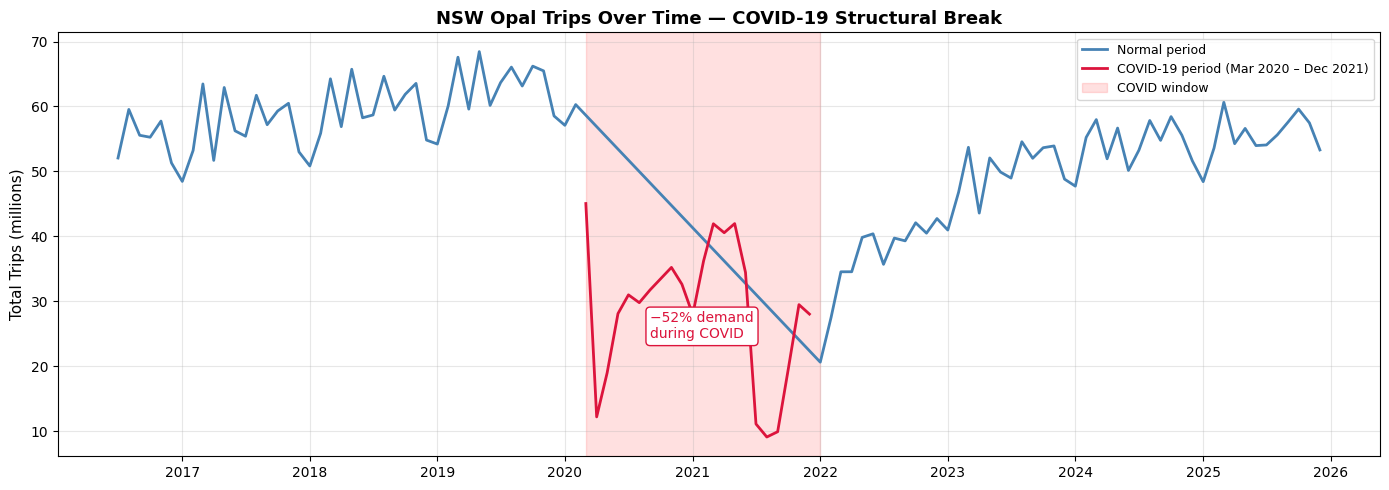

Saved: covid_timeseries.png


In [13]:
# ── EDA 2: TOTAL TRIPS OVER TIME WITH COVID ANNOTATION ───────────────────────
# Shows the full time-series with COVID structural break clearly marked.
# This chart motivates the use of COVID_Flag and Post_COVID_Recovery dummies.
# Authored by: Suyog Kadariya

fig, ax = plt.subplots(figsize=(14, 5))

normal_data = merged_clean[merged_clean['COVID_Flag'] == 0]
covid_data  = merged_clean[merged_clean['COVID_Flag'] == 1]

ax.plot(normal_data['Date'], normal_data['Total_Trips']/1e6,
        color='steelblue', linewidth=2, label='Normal period')
ax.plot(covid_data['Date'], covid_data['Total_Trips']/1e6,
        color='crimson', linewidth=2, label='COVID-19 period (Mar 2020 – Dec 2021)')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           alpha=0.12, color='red', label='COVID window')
ax.annotate(f'−{pct_drop:.0f}% demand\nduring COVID',
            xy=(pd.Timestamp('2020-09-01'), covid_mean * 0.85),
            fontsize=10, color='crimson',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='crimson'))

ax.set_ylabel('Total Trips (millions)', fontsize=11)
ax.set_title('NSW Opal Trips Over Time — COVID-19 Structural Break', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('covid_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: covid_timeseries.png")

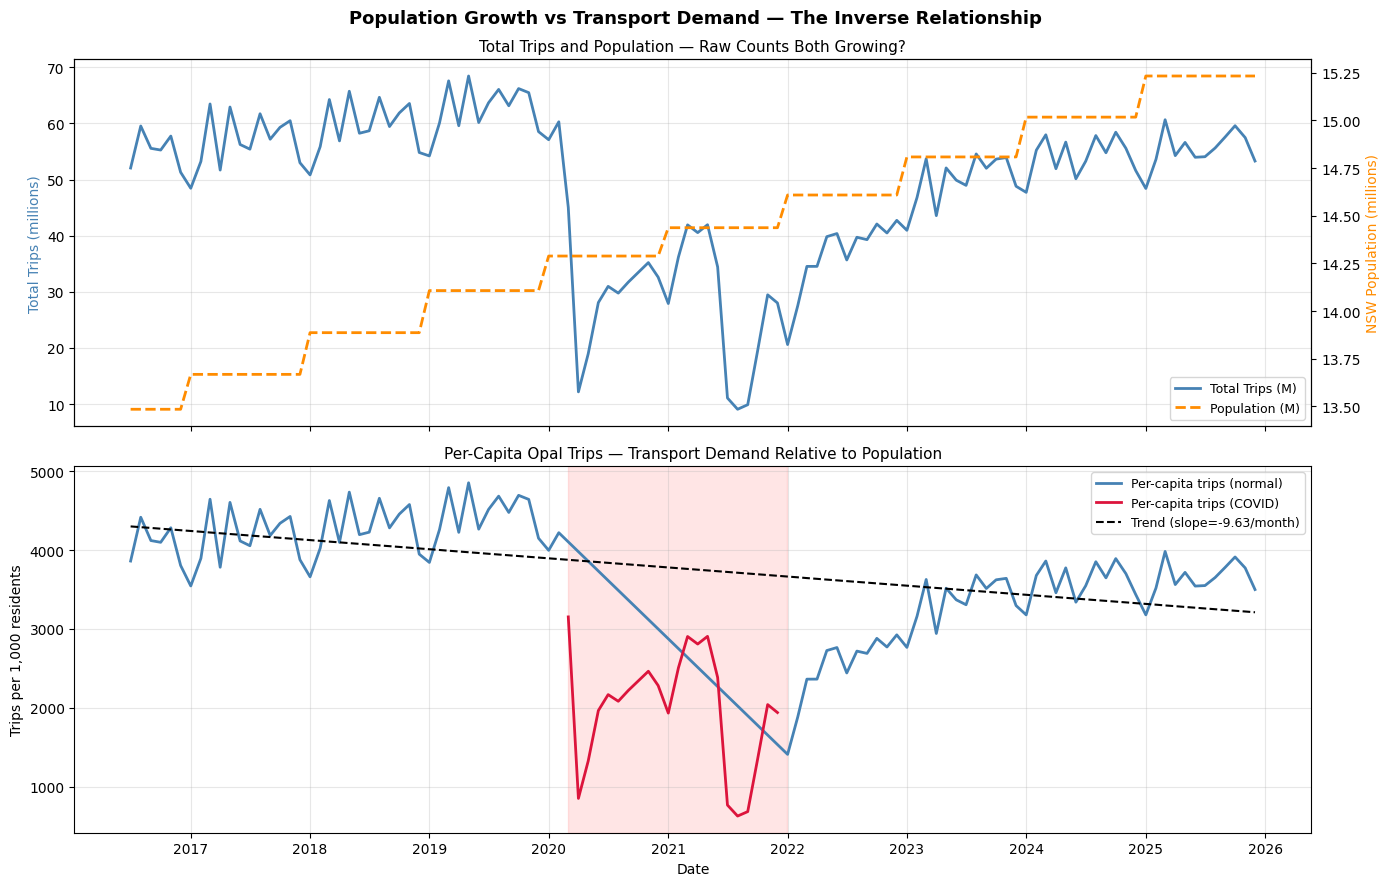

KEY FINDING — PER CAPITA TRIPS:
  Pre-COVID average:  4264.6 trips per 1,000 residents/month
  Post-COVID average: 3279.7 trips per 1,000 residents/month
  Trend slope (non-COVID): -9.6253 per month
  → Per-capita demand is DECLINING despite population growth
Saved: per_capita_trips.png


In [14]:
# ── EDA 3: PER-CAPITA TRIPS — THE INVERSE RELATIONSHIP ───────────────────────
# KEY FINDING: When we normalise trips by population, per-capita demand is
# DECLINING even before COVID. This directly challenges the assumption that
# population growth drives transit demand.
# Authored by: Nasla Maharjan

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Population Growth vs Transport Demand — The Inverse Relationship',
             fontsize=13, fontweight='bold')

# Top panel: dual-axis trips vs population
ax1      = axes[0]
ax1_twin = ax1.twinx()
ax1.plot(merged_clean['Date'], merged_clean['Total_Trips']/1e6,
         color='steelblue', linewidth=2, label='Total Trips (M)')
ax1_twin.plot(merged_clean['Date'], merged_clean['Total_Population']/1e6,
              color='darkorange', linewidth=2, linestyle='--', label='Population (M)')
ax1.set_ylabel('Total Trips (millions)', color='steelblue', fontsize=10)
ax1_twin.set_ylabel('NSW Population (millions)', color='darkorange', fontsize=10)
ax1.set_title('Total Trips and Population — Raw Counts Both Growing?', fontsize=11)
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower right')

# Bottom panel: per-capita (the real story)
ax2       = axes[1]
non_covid = merged_clean[merged_clean['COVID_Flag'] == 0].copy()
covid_rows = merged_clean[merged_clean['COVID_Flag'] == 1].copy()

ax2.plot(non_covid['Date'], non_covid['Per_Capita_Trips'],
         color='steelblue', linewidth=2, label='Per-capita trips (normal)')
ax2.plot(covid_rows['Date'], covid_rows['Per_Capita_Trips'],
         color='crimson', linewidth=2, label='Per-capita trips (COVID)')
ax2.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='red')

# Trend line on non-COVID data only (shows structural pre-COVID decline)
z = np.polyfit(non_covid['Time_Index'], non_covid['Per_Capita_Trips'], 1)
p_trend = np.poly1d(z)
ax2.plot(non_covid['Date'], p_trend(non_covid['Time_Index']),
         'k--', linewidth=1.5, label=f'Trend (slope={z[0]:.2f}/month)')

ax2.set_ylabel('Trips per 1,000 residents', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.set_title('Per-Capita Opal Trips — Transport Demand Relative to Population', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('per_capita_trips.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the key numerical finding
pre_covid_pc  = merged_clean.loc[merged_clean['Date'] < '2020-03-01', 'Per_Capita_Trips'].mean()
post_covid_pc = merged_clean.loc[merged_clean['Date'] > '2021-12-31', 'Per_Capita_Trips'].mean()
print("KEY FINDING — PER CAPITA TRIPS:")
print(f"  Pre-COVID average:  {pre_covid_pc:.1f} trips per 1,000 residents/month")
print(f"  Post-COVID average: {post_covid_pc:.1f} trips per 1,000 residents/month")
print(f"  Trend slope (non-COVID): {z[0]:.4f} per month")
print(f"  → Per-capita demand is DECLINING despite population growth")
print("Saved: per_capita_trips.png")

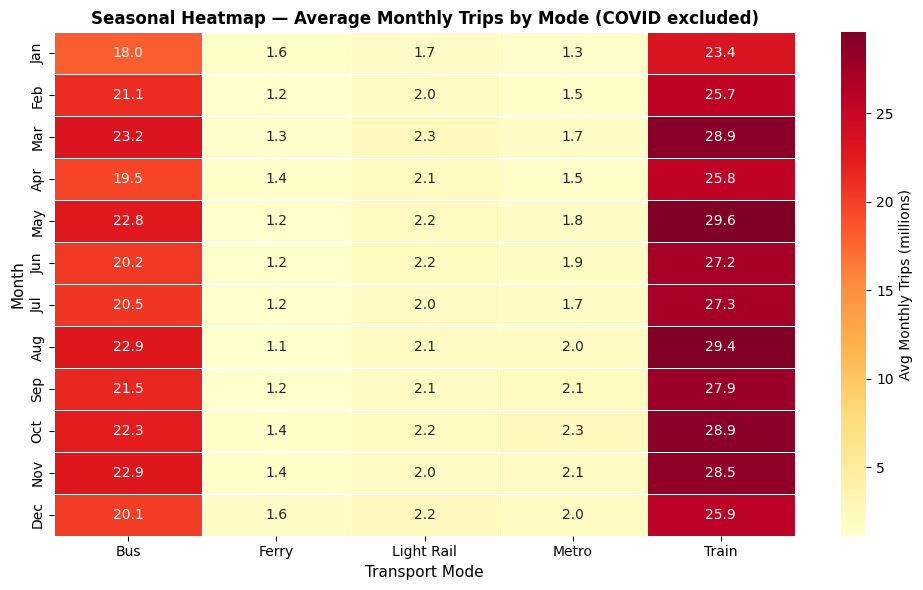

Saved: seasonal_heatmap.png
Observation: School-term months (Feb–Jun, Jul–Nov) show higher demand.
Conclusion: Seasonality is real and must be modelled (Month feature justified).


In [15]:
# ── EDA 4: SEASONAL HEATMAP — MONTH × TRAVEL MODE ────────────────────────────
# Shows average monthly trips per mode by calendar month (COVID excluded).
# Modelling decision: visible seasonality here justifies including Month
# as a feature in Model 3 (Ridge regression).
# Authored by: Krish Rajbhandari

heatmap_data = merged_clean[merged_clean['COVID_Flag'] == 0].copy()
heatmap_data['Month_Num'] = heatmap_data['Date'].dt.month
seasonal_pivot = heatmap_data.groupby('Month_Num')[mode_cols].mean() / 1e6
seasonal_pivot.index = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(seasonal_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Monthly Trips (millions)'})
ax.set_title('Seasonal Heatmap — Average Monthly Trips by Mode (COVID excluded)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Transport Mode', fontsize=11)
ax.set_ylabel('Month', fontsize=11)
plt.tight_layout()
plt.savefig('seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: seasonal_heatmap.png")
print("Observation: School-term months (Feb–Jun, Jul–Nov) show higher demand.")
print("Conclusion: Seasonality is real and must be modelled (Month feature justified).")

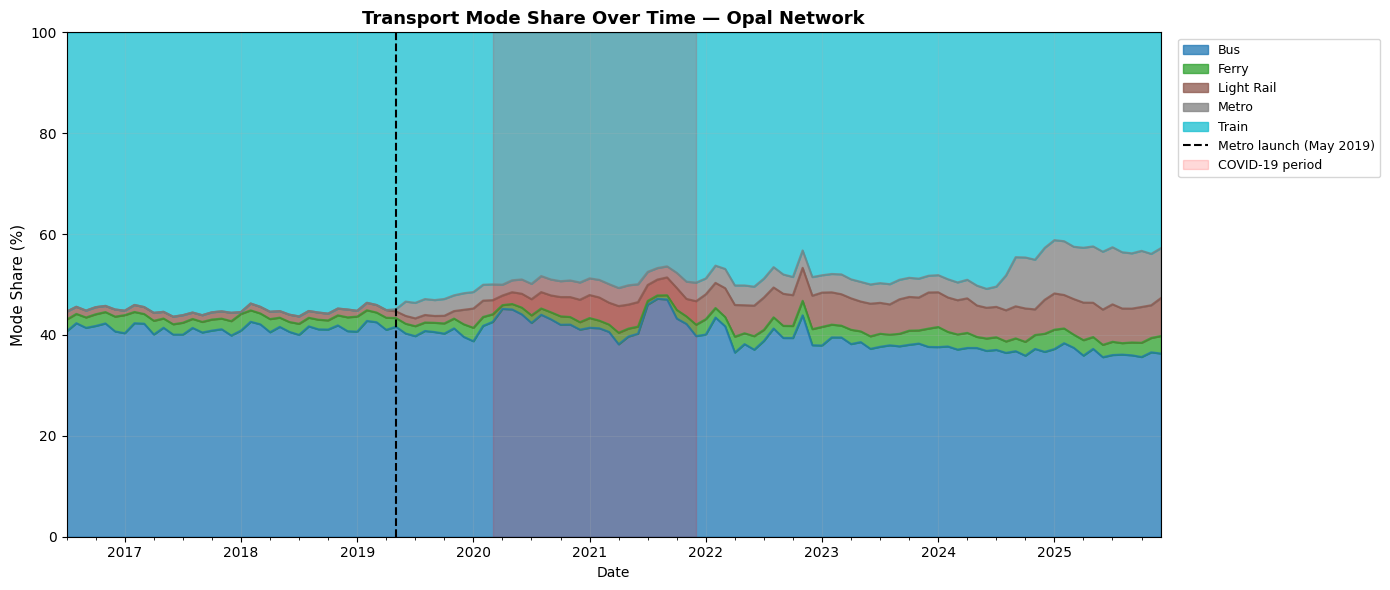

Saved: mode_share.png


In [16]:
# ── EDA 5: MODE SHARE STACKED AREA CHART ──────────────────────────────────────
# Shows how the proportion of each mode has shifted over 2016–2025.
# Metro entry (May 2019) is expected to take share from Bus and Train.
# Authored by: Suyog Kadariya

prop_df = merged_clean[['Date'] + mode_cols].copy().set_index('Date')
prop_df = prop_df.div(prop_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
prop_df.plot.area(ax=ax, alpha=0.75, colormap='tab10')
if 'Metro' in prop_df.columns:
    ax.axvline(pd.Timestamp('2019-05-01'), color='black',
               linestyle='--', linewidth=1.5, label='Metro launch (May 2019)')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           alpha=0.15, color='red', label='COVID-19 period')
ax.set_ylabel('Mode Share (%)', fontsize=11)
ax.set_title('Transport Mode Share Over Time — Opal Network', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, bbox_to_anchor=(1.01, 1))
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('mode_share.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mode_share.png")

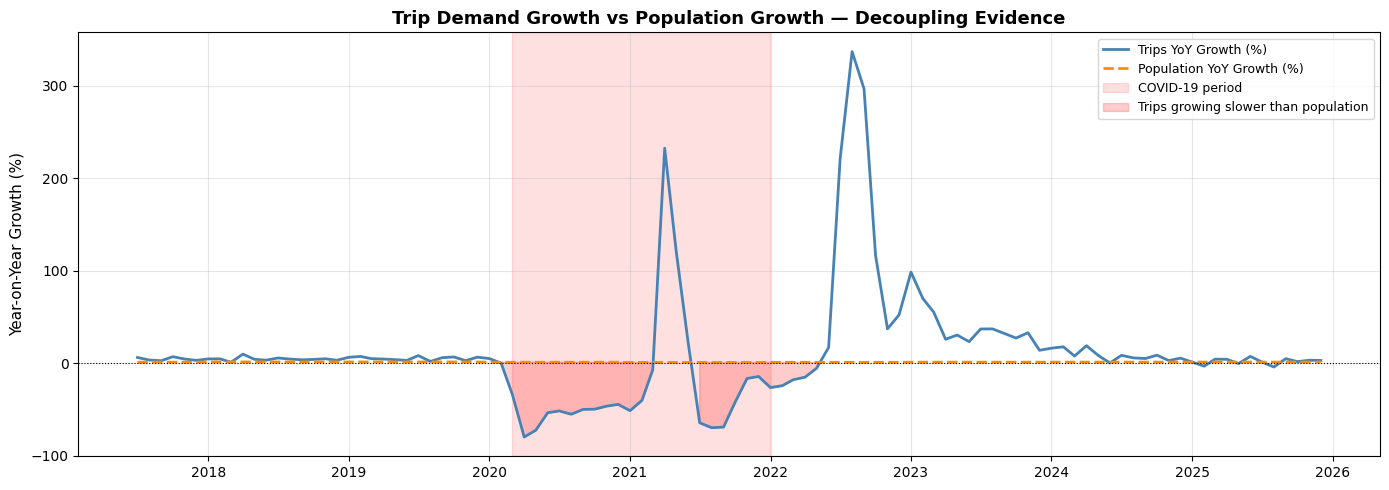

Saved: yoy_growth_comparison.png


In [17]:
# ── EDA 6: YoY GROWTH — TRIPS vs POPULATION DECOUPLING ───────────────────────
# Visualises the divergence between population growth and trip demand growth.
# Red shading = periods where trips grew slower than population.
# This is the visual proof of the inverse/decoupled relationship we model.
# Authored by: Krish Rajbhandari

growth_data = merged_clean[['Date','Trips_YoY_Growth','Population_YoY_Growth']].dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(growth_data['Date'], growth_data['Trips_YoY_Growth'],
        color='steelblue', linewidth=2, label='Trips YoY Growth (%)')
ax.plot(growth_data['Date'], growth_data['Population_YoY_Growth'],
        color='darkorange', linewidth=2, linestyle='--', label='Population YoY Growth (%)')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           alpha=0.12, color='red', label='COVID-19 period')
ax.fill_between(growth_data['Date'],
                growth_data['Trips_YoY_Growth'], growth_data['Population_YoY_Growth'],
                where=(growth_data['Trips_YoY_Growth'] < growth_data['Population_YoY_Growth']),
                alpha=0.2, color='red', label='Trips growing slower than population')
ax.set_ylabel('Year-on-Year Growth (%)', fontsize=11)
ax.set_title('Trip Demand Growth vs Population Growth — Decoupling Evidence',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('yoy_growth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: yoy_growth_comparison.png")

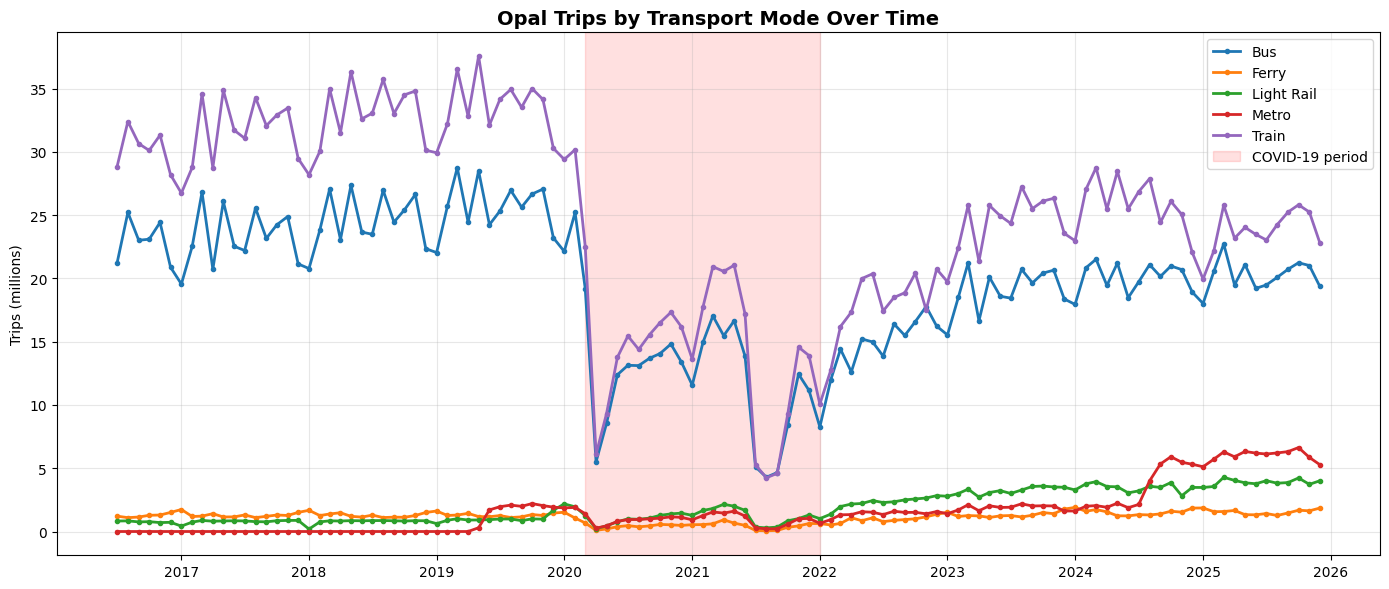

Saved: trips_by_mode.png


In [18]:
# ── EDA 7: TRIPS BY TRANSPORT MODE OVER TIME ──────────────────────────────────
# Line chart showing absolute trip counts per mode.
# Identifies which modes drive overall demand changes.
# Authored by: Suyog Kadariya

fig, ax = plt.subplots(figsize=(14, 6))
for mode in mode_cols:
    ax.plot(merged_clean['Date'], merged_clean[mode]/1e6,
            marker='o', label=mode, markersize=3, linewidth=2)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           alpha=0.12, color='red', label='COVID-19 period')
ax.set_ylabel('Trips (millions)')
ax.set_title('Opal Trips by Transport Mode Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('trips_by_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: trips_by_mode.png")

---
## 6. Regression Modelling
**Three models are built with increasing complexity:**

| Model | Type | Features | Purpose |
|---|---|---|---|
| M1 | Simple Log-Log OLS | ln(Population) | Baseline: does population predict demand? |
| M2 | Multiple OLS | + Time_Index, Pop_YoY_Growth, COVID_Flag | Does service/time + COVID improve fit? |
| M3 | Ridge (L2 regularised) | + Post_COVID_Recovery, Month | Handles multicollinearity; adds seasonality |

**Why log-log specification?**
The log-log model gives a direct elasticity interpretation: the coefficient β₁ = % change
in trips for a 1% change in population. This is standard in transport demand economics.

**Why Ridge for M3?**
Log_Population and Time_Index are correlated (both trend upward), creating multicollinearity.
Ridge L2 regularisation shrinks unstable correlated coefficients, producing more reliable estimates.
RidgeCV automatically selects the optimal penalty λ via 5-fold cross-validation.

In [19]:
# ── BUILD REGRESSION DATASET ──────────────────────────────────────────────────
# All three models are trained on the SAME 102-observation dataset.
# This is essential for fair statistical comparison (paired tests).
# dropna() removes the first 12 months where YoY growth rates are undefined.
# Authored by: Krish Rajbhandari

regression_full = merged_clean[[
    'Date', 'Log_Total_Trips', 'Log_Population',
    'Time_Index', 'Population_YoY_Growth',
    'COVID_Flag', 'Post_COVID_Recovery', 'Month'
]].dropna().reset_index(drop=True)

y_full = regression_full['Log_Total_Trips'].values

print(f"Regression dataset: {len(regression_full)} observations")
print(f"Date range: {regression_full['Date'].min().date()} to {regression_full['Date'].max().date()}")
regression_full.describe()

Regression dataset: 102 observations
Date range: 2017-07-01 to 2025-12-01


,Date,Log_Total_Trips,Log_Population,Time_Index,Population_YoY_Growth,COVID_Flag,Post_COVID_Recovery,Month
count,102,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,2021-09-15 15:45:52.941176,17.626008,16.488900,62.500000,1.363206,0.215686,0.470588,6.676471
min,2017-07-01 00:00:00,16.022332,16.430591,12.000000,1.039109,0.000000,0.000000,1.000000
25%,2019-08-08 18:00:00,17.503629,16.462218,37.250000,1.283529,0.000000,0.000000,4.000000
50%,2021-09-16 00:00:00,17.794248,16.485309,62.500000,1.366165,0.000000,0.000000,7.000000
75%,2023-10-24 06:00:00,17.879104,16.510682,87.750000,1.435934,0.000000,1.000000,10.000000
max,2025-12-01 00:00:00,18.041607,16.538931,113.000000,1.599393,1.000000,1.000000,12.000000
std,NaN,0.408819,0.032234,29.588849,0.174477,0.413329,0.501599,3.464564


In [20]:
# ── MODEL 1: SIMPLE LOG-LOG REGRESSION (BASELINE) ────────────────────────────
# Equation: ln(Total_Trips) = β₀ + β₁ × ln(Population)
# Purpose: establishes whether population growth alone predicts transit demand.
# Expected result based on EDA: R² will be very low — population is not sufficient.
# Authored by: Nasla Maharjan

X_m1      = regression_full[['Log_Population']].values
model1_f  = LinearRegression().fit(X_m1, y_full)
y_pred1_f = model1_f.predict(X_m1)
residuals_1f = y_full - y_pred1_f

r2_1f   = r2_score(y_full, y_pred1_f)
rmse_1f = np.sqrt(mean_squared_error(y_full, y_pred1_f))
mae_1f  = mean_absolute_error(y_full, y_pred1_f)

print("MODEL 1 — Simple Log-Log Regression")
print(f"  Equation: ln(Trips) = {model1_f.intercept_:.3f} + {model1_f.coef_[0]:.4f} × ln(Pop)")
print(f"  Elasticity: 1% population growth → {model1_f.coef_[0]:.3f}% trip change")
print(f"  R²  = {r2_1f:.4f}  ({r2_1f*100:.2f}% variance explained)")
print(f"  RMSE = {rmse_1f:.6f}")
print(f"  MAE  = {mae_1f:.6f}")
print(f"\n  Interpretation: Population explains only {r2_1f*100:.2f}% of variance.")
print(f"  Negative elasticity ({model1_f.coef_[0]:.3f}) confirms the inverse relationship.")

MODEL 1 — Simple Log-Log Regression
  Equation: ln(Trips) = 24.442 + -0.4134 × ln(Pop)
  Elasticity: 1% population growth → -0.413% trip change
  R²  = 0.0011  (0.11% variance explained)
  RMSE = 0.406594
  MAE  = 0.296602

  Interpretation: Population explains only 0.11% of variance.
  Negative elasticity (-0.413) confirms the inverse relationship.


In [21]:
# ── MODEL 2: MULTIPLE OLS WITH COVID DUMMY ────────────────────────────────────
# Equation: ln(Trips) = β₀ + β₁·ln(Pop) + β₂·Time + β₃·PopGrowth + β₄·COVID
# Adding Time_Index captures cumulative infrastructure/service improvements.
# COVID_Flag is essential — without it, the COVID demand drop is misattributed
# to population or time trend, biasing all other coefficients.
# Authored by: Nasla Maharjan

X_m2      = regression_full[['Log_Population','Time_Index',
                               'Population_YoY_Growth','COVID_Flag']].values
model2_f  = LinearRegression().fit(X_m2, y_full)
y_pred2_f = model2_f.predict(X_m2)
residuals_2f = y_full - y_pred2_f

r2_2f   = r2_score(y_full, y_pred2_f)
rmse_2f = np.sqrt(mean_squared_error(y_full, y_pred2_f))
mae_2f  = mean_absolute_error(y_full, y_pred2_f)

m2_names = ['ln(Population)', 'Time_Index', 'Pop_YoY_Growth', 'COVID_Flag']
print("MODEL 2 — Multiple OLS + COVID Flag")
print(f"  Intercept: {model2_f.intercept_:.4f}")
for n, c in zip(m2_names, model2_f.coef_):
    print(f"  {n:20s}: {c:+.6f}")
print(f"\n  R²  = {r2_2f:.4f}  (+{r2_2f-r2_1f:.4f} improvement over M1)")
print(f"  RMSE = {rmse_2f:.6f}")
print(f"  MAE  = {mae_2f:.6f}")
print(f"\n  COVID effect (OLS unstandardised): {model2_f.coef_[3]:.4f} log-units")
print(f"  → e^({model2_f.coef_[3]:.4f}) = {np.exp(model2_f.coef_[3]):.3f}")
print(f"  → Model estimates COVID reduced trips by ~{(1-np.exp(model2_f.coef_[3]))*100:.1f}%")
print(f"  Note: Raw data shows 47% — OLS estimate is lower because Time_Index")
print(f"        absorbs part of the COVID effect.")

MODEL 2 — Multiple OLS + COVID Flag
  Intercept: 76.2039
  ln(Population)      : -3.651798
  Time_Index          : +0.004085
  Pop_YoY_Growth      : +1.077919
  COVID_Flag          : -0.410191

  R²  = 0.6266  (+0.6255 improvement over M1)
  RMSE = 0.248593
  MAE  = 0.148318

  COVID effect (OLS unstandardised): -0.4102 log-units
  → e^(-0.4102) = 0.664
  → Model estimates COVID reduced trips by ~33.6%
  Note: Raw data shows 47% — OLS estimate is lower because Time_Index
        absorbs part of the COVID effect.


In [22]:
# ── MODEL 3: RIDGE REGRESSION (L2 REGULARISATION) ────────────────────────────
# Features: all M2 features + Post_COVID_Recovery + Month
#
# Why Ridge over OLS:
#   Log_Population and Time_Index are strongly correlated (both trend upward)
#   → multicollinearity inflates OLS coefficient variance
#   Ridge adds L2 penalty: minimises (RSS + λ × Σβ²)
#   This shrinks correlated coefficients toward zero, improving stability
#
# Why Post_COVID_Recovery:
#   Without it, Time_Index goes negative (later dates = lower trips post-COVID)
#   This flag absorbs the new lower demand baseline post-2022
#   Allowing Time_Index to correctly capture pre-COVID growth trend
#
# Features are standardised before Ridge (Ridge is scale-sensitive; OLS is not)
# RidgeCV selects optimal λ via 5-fold cross-validation
# Authored by: Krish Rajbhandari

feature_cols_ridge = ['Log_Population', 'Time_Index', 'Population_YoY_Growth',
                      'COVID_Flag', 'Post_COVID_Recovery', 'Month']

X_ridge        = regression_full[feature_cols_ridge].values
scaler         = StandardScaler()
X_ridge_scaled = scaler.fit_transform(X_ridge)

# Search 100 candidate λ values from 0.001 to 1000 (log-spaced)
alphas   = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
ridge_cv.fit(X_ridge_scaled, y_full)

y_pred3     = ridge_cv.predict(X_ridge_scaled)
residuals_3 = y_full - y_pred3
r2_3   = r2_score(y_full, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y_full, y_pred3))
mae_3  = mean_absolute_error(y_full, y_pred3)

print("MODEL 3 — Ridge Regression (L2, CV-tuned)")
print(f"  Optimal λ (selected by 5-fold CV): {ridge_cv.alpha_:.4f}")
print(f"  R²  = {r2_3:.4f}  (+{r2_3-r2_2f:.4f} over M2)")
print(f"  RMSE = {rmse_3:.6f}")
print(f"  MAE  = {mae_3:.6f}")
print(f"\n  Standardised coefficients (show relative feature importance):")
for fname, coef in zip(feature_cols_ridge, ridge_cv.coef_):
    bar = '█' * int(abs(coef) * 50)
    sign = '+' if coef > 0 else '-'
    print(f"  {fname:28s}: {coef:+.4f}  {sign}{bar}")

print(f"\n  Time_Index coefficient: {ridge_cv.coef_[1]:+.4f}")
if ridge_cv.coef_[1] > 0:
    print(f"  ✓ POSITIVE — correctly captures pre-COVID growth trend")
else:
    print(f"  ⚠ Negative — investigate further")

print(f"\nMODEL PROGRESSION SUMMARY:")
print(f"  M1 (population only):              R² = {r2_1f:.4f}")
print(f"  M2 (+ time + COVID):               R² = {r2_2f:.4f}  (+{r2_2f-r2_1f:.4f})")
print(f"  M3 (+ recovery + month, Ridge):    R² = {r2_3:.4f}  (+{r2_3-r2_2f:.4f})")

MODEL 3 — Ridge Regression (L2, CV-tuned)
  Optimal λ (selected by 5-fold CV): 0.0046
  R²  = 0.6491  (+0.0226 over M2)
  RMSE = 0.240967
  MAE  = 0.141814

  Standardised coefficients (show relative feature importance):
  Log_Population              : -0.7449  -█████████████████████████████████████
  Time_Index                  : +0.9355  +██████████████████████████████████████████████
  Population_YoY_Growth       : +0.1511  +███████
  COVID_Flag                  : -0.2796  -█████████████
  Post_COVID_Recovery         : -0.2478  -████████████
  Month                       : -0.0873  -████

  Time_Index coefficient: +0.9355
  ✓ POSITIVE — correctly captures pre-COVID growth trend

MODEL PROGRESSION SUMMARY:
  M1 (population only):              R² = 0.0011
  M2 (+ time + COVID):               R² = 0.6266  (+0.6255)
  M3 (+ recovery + month, Ridge):    R² = 0.6491  (+0.0226)


---
## 7. Statistical Testing
**Five tests are performed:**
1. **t-test on M1 coefficient** — is the population elasticity significantly different from zero?
2. **F-test on M1** — does the overall model explain significant variance?
3. **Shapiro-Wilk** — are residuals normally distributed? (OLS assumption check)
4. **Paired t-test** — does each model significantly outperform the previous one?
5. **Wilcoxon signed-rank** — non-parametric alternative when normality is violated
6. **Durbin-Watson** — is there autocorrelation in residuals? (time-series concern)

In [23]:
# ── TEST 1: COEFFICIENT T-TEST (MODEL 1) ──────────────────────────────────────
# Tests whether β₁ (population elasticity) is significantly different from zero.
# Calculated manually from scratch to demonstrate statistical understanding.
# H₀: β₁ = 0 (population has no effect on trips)
# H₁: β₁ ≠ 0 (population has a significant effect)
# Authored by: Krish Rajbhandari

n = len(y_full)
k = 2  # intercept + 1 predictor
se_resid = np.sqrt(np.sum(residuals_1f**2) / (n - k))
X_const  = np.column_stack([np.ones(n), X_m1])
XtX_inv  = np.linalg.inv(X_const.T @ X_const)
se_coef  = se_resid * np.sqrt(np.diag(XtX_inv))

t_stat_b1   = model1_f.coef_[0] / se_coef[1]
p_value_b1  = 2 * (1 - stats.t.cdf(abs(t_stat_b1), n - 2))

print("TEST 1: COEFFICIENT T-TEST — Model 1 Population Elasticity")
print(f"  H₀: β₁ = 0  |  H₁: β₁ ≠ 0")
print(f"  β₁ estimate:  {model1_f.coef_[0]:.6f}")
print(f"  Std. Error:   {se_coef[1]:.6f}")
print(f"  t-statistic:  {t_stat_b1:.4f}")
print(f"  p-value:      {p_value_b1:.4e}")
sig = 'Yes — β₁ is significant' if p_value_b1 < 0.05 else 'No — β₁ is NOT significant'
print(f"  Significant:  {sig}")

TEST 1: COEFFICIENT T-TEST — Model 1 Population Elasticity
  H₀: β₁ = 0  |  H₁: β₁ ≠ 0
  β₁ estimate:  -0.413356
  Std. Error:   1.267626
  t-statistic:  -0.3261
  p-value:      7.4504e-01
  Significant:  No — β₁ is NOT significant


In [24]:
# ── TEST 2: F-TEST — MODEL 1 OVERALL SIGNIFICANCE ────────────────────────────
# Tests whether Model 1 as a whole explains significantly more variance than
# a model with just the intercept (i.e., is R² meaningfully above zero?)
# H₀: R² = 0 (model explains no variance)
# H₁: R² > 0 (model explains significant variance)
# Authored by: Krish Rajbhandari

ss_res  = np.sum(residuals_1f**2)
ss_tot  = np.sum((y_full - np.mean(y_full))**2)
ss_reg  = ss_tot - ss_res
f_stat  = (ss_reg / (k - 1)) / (ss_res / (n - k))
f_pval  = 1 - stats.f.cdf(f_stat, k - 1, n - k)

print("TEST 2: F-TEST — Model 1 Overall Significance")
print(f"  H₀: R² = 0  |  H₁: R² > 0")
print(f"  F-statistic:  {f_stat:.4f}")
print(f"  df:           ({k-1}, {n-k})")
print(f"  p-value:      {f_pval:.4e}")
print(f"  Decision:     {'REJECT H₀ — model is significant' if f_pval < 0.05 else 'FAIL TO REJECT H₀'}")

TEST 2: F-TEST — Model 1 Overall Significance
  H₀: R² = 0  |  H₁: R² > 0
  F-statistic:  0.1063
  df:           (1, 100)
  p-value:      7.4504e-01
  Decision:     FAIL TO REJECT H₀


In [25]:
# ── TEST 3: SHAPIRO-WILK NORMALITY TEST ───────────────────────────────────────
# OLS assumes normally distributed residuals for valid inference.
# We test this formally on all three models rather than relying only on Q-Q plots.
# H₀: Residuals are normally distributed
# H₁: Residuals are NOT normally distributed
# If H₀ is rejected, we use Wilcoxon (non-parametric) as our primary comparison test.
# Authored by: Krish Rajbhandari

print("TEST 3: SHAPIRO-WILK NORMALITY TEST ON RESIDUALS")
print(f"  H₀: Residuals ~ Normal  |  α = 0.05")
print()
for name, res in [('M1 Simple Log-Log',      residuals_1f),
                  ('M2 Multiple OLS + COVID', residuals_2f),
                  ('M3 Ridge',               residuals_3)]:
    w, p = shapiro(res)
    result = 'NORMAL ✓' if p > 0.05 else 'NON-NORMAL ✗ → use Wilcoxon'
    print(f"  {name:28s}: W={w:.4f}, p={p:.3e}  → {result}")

TEST 3: SHAPIRO-WILK NORMALITY TEST ON RESIDUALS
  H₀: Residuals ~ Normal  |  α = 0.05

  M1 Simple Log-Log           : W=0.7585, p=1.170e-11  → NON-NORMAL ✗ → use Wilcoxon
  M2 Multiple OLS + COVID     : W=0.8172, p=6.633e-10  → NON-NORMAL ✗ → use Wilcoxon
  M3 Ridge                    : W=0.7814, p=5.176e-11  → NON-NORMAL ✗ → use Wilcoxon


In [26]:
# ── TEST 4: PAIRED T-TEST — MODEL COMPARISON ──────────────────────────────────
# Compares absolute prediction errors between models.
# Smaller absolute errors = better model performance.
# One-tailed test: H₁ = later model has SMALLER errors than earlier model.
# H₀: Mean(|errors_A|) = Mean(|errors_B|)  — no difference in accuracy
# H₁: Mean(|errors_B|) < Mean(|errors_A|)  — later model is more accurate
# Authored by: Krish Rajbhandari

abs_err_1 = np.abs(residuals_1f)
abs_err_2 = np.abs(residuals_2f)
abs_err_3 = np.abs(residuals_3)

print("TEST 4: PAIRED T-TEST — Model Comparison")
print(f"  One-tailed, α = 0.05")
print()
comparisons = [
    ('M1 vs M2', abs_err_1, abs_err_2),
    ('M2 vs M3', abs_err_2, abs_err_3),
    ('M1 vs M3', abs_err_1, abs_err_3),
]
for label, e1, e2 in comparisons:
    t, p_two = stats.ttest_rel(e1, e2)
    p_one    = p_two / 2
    improved = e2.mean() < e1.mean()
    sig      = p_one < 0.05 and improved
    decision = 'SIGNIFICANT IMPROVEMENT ✓' if sig else 'NOT SIGNIFICANT'
    print(f"  {label}: MAE {e1.mean():.5f} → {e2.mean():.5f}")
    print(f"         t={t:.3f}, p(one-tail)={p_one:.4e}  → {decision}")
    print()

TEST 4: PAIRED T-TEST — Model Comparison
  One-tailed, α = 0.05

  M1 vs M2: MAE 0.29660 → 0.14832
         t=7.379, p(one-tail)=2.2917e-11  → SIGNIFICANT IMPROVEMENT ✓

  M2 vs M3: MAE 0.14832 → 0.14181
         t=1.178, p(one-tail)=1.2074e-01  → NOT SIGNIFICANT

  M1 vs M3: MAE 0.29660 → 0.14181
         t=8.121, p(one-tail)=5.8898e-13  → SIGNIFICANT IMPROVEMENT ✓



In [27]:
# ── TEST 5: WILCOXON SIGNED-RANK TEST (NON-PARAMETRIC) ───────────────────────
# Because Shapiro-Wilk confirmed non-normal residuals in all three models,
# this non-parametric test is our PRIMARY model comparison method.
# It makes no normality assumption and is robust to outliers.
# H₀: No difference in prediction errors between models
# H₁: There is a significant difference in prediction errors
# Authored by: Krish Rajbhandari

print("TEST 5: WILCOXON SIGNED-RANK TEST (Primary model comparison)")
print(f"  Non-parametric — used because Shapiro-Wilk rejected normality")
print(f"  H₀: No difference in prediction errors  |  α = 0.05")
print()
for label, e1, e2 in comparisons:
    w, p = wilcoxon(e1, e2)
    decision = 'SIGNIFICANT ✓' if p < 0.05 else 'NOT SIGNIFICANT'
    print(f"  {label}: W={w:.1f}, p={p:.4e}  → {decision}")

TEST 5: WILCOXON SIGNED-RANK TEST (Primary model comparison)
  Non-parametric — used because Shapiro-Wilk rejected normality
  H₀: No difference in prediction errors  |  α = 0.05

  M1 vs M2: W=586.0, p=9.6546e-12  → SIGNIFICANT ✓
  M2 vs M3: W=2296.0, p=2.6991e-01  → NOT SIGNIFICANT
  M1 vs M3: W=497.0, p=1.1718e-12  → SIGNIFICANT ✓


In [28]:
# ── TEST 6: DURBIN-WATSON AUTOCORRELATION ─────────────────────────────────────
# Checks whether residuals are correlated with adjacent time periods.
# Monthly time-series data often exhibits autocorrelation.
# DW ≈ 2 = no autocorrelation; DW < 1.5 = positive autocorrelation
# Implication: standard errors may be underestimated if autocorrelation is present.
# Authored by: Krish Rajbhandari

print("TEST 6: DURBIN-WATSON AUTOCORRELATION TEST")
print(f"  DW ≈ 2: no autocorrelation | DW < 1.5: positive autocorrelation")
print()
for name, res in [('M1', residuals_1f), ('M2', residuals_2f), ('M3', residuals_3)]:
    dw     = np.sum(np.diff(res)**2) / np.sum(res**2)
    interp = 'acceptable (≈2)' if 1.5 < dw < 2.5 else ('positive autocorrelation' if dw < 1.5 else 'negative autocorrelation')
    print(f"  {name}: DW = {dw:.4f}  → {interp}")
print()
print("  Note: Autocorrelation is expected in monthly data.")
print("  Implication: standard errors may be slightly underestimated.")
print("  Recommendation for future work: use ARIMA models for forecasting.")

TEST 6: DURBIN-WATSON AUTOCORRELATION TEST
  DW ≈ 2: no autocorrelation | DW < 1.5: positive autocorrelation

  M1: DW = 0.3028  → positive autocorrelation
  M2: DW = 0.9286  → positive autocorrelation
  M3: DW = 0.9462  → positive autocorrelation

  Note: Autocorrelation is expected in monthly data.
  Implication: standard errors may be slightly underestimated.
  Recommendation for future work: use ARIMA models for forecasting.


---
## 8. Model Comparison & Evaluation

In [29]:
# ── FINAL MODEL COMPARISON TABLE ──────────────────────────────────────────────
# All three models on the same 102-observation dataset for fair comparison.
# Authored by: Krish Rajbhandari

model_comparison = pd.DataFrame({
    'Model':    ['M1: Simple Log-Log', 'M2: Multiple OLS + COVID', 'M3: Ridge (CV-tuned)'],
    'Equation': [
        'ln(T) ~ ln(Pop)',
        'ln(T) ~ ln(Pop) + Time + PopGrowth + COVID',
        'ln(T) ~ all + Recovery + Month  [L2]'
    ],
    'R²':        [round(r2_1f,4),   round(r2_2f,4),   round(r2_3,4)],
    'RMSE':      [round(rmse_1f,5), round(rmse_2f,5), round(rmse_3,5)],
    'MAE':       [round(mae_1f,5),  round(mae_2f,5),  round(mae_3,5)],
    'λ (Ridge)': ['—', '—', f'{ridge_cv.alpha_:.4f}']
})

print("=" * 90)
print("FINAL MODEL COMPARISON — All models trained on 102 observations")
print("=" * 90)
print(model_comparison.to_string(index=False))

best = model_comparison.loc[model_comparison['R²'].idxmax()]
print(f"\n★ Best model: {best['Model']} with R² = {best['R²']}")
print(f"  Explains {best['R²']*100:.1f}% of variance in monthly Opal demand.")
print(f"  Remaining {(1-best['R²'])*100:.1f}% is unexplained variance from:")
print(f"  service quality, fuel prices, weather, WFH rates, major events.")

FINAL MODEL COMPARISON — All models trained on 102 observations
                   Model                                   Equation     R²    RMSE     MAE λ (Ridge)
      M1: Simple Log-Log                            ln(T) ~ ln(Pop) 0.0011 0.40659 0.29660         —
M2: Multiple OLS + COVID ln(T) ~ ln(Pop) + Time + PopGrowth + COVID 0.6266 0.24859 0.14832         —
    M3: Ridge (CV-tuned)       ln(T) ~ all + Recovery + Month  [L2] 0.6491 0.24097 0.14181    0.0046

★ Best model: M3: Ridge (CV-tuned) with R² = 0.6491
  Explains 64.9% of variance in monthly Opal demand.
  Remaining 35.1% is unexplained variance from:
  service quality, fuel prices, weather, WFH rates, major events.


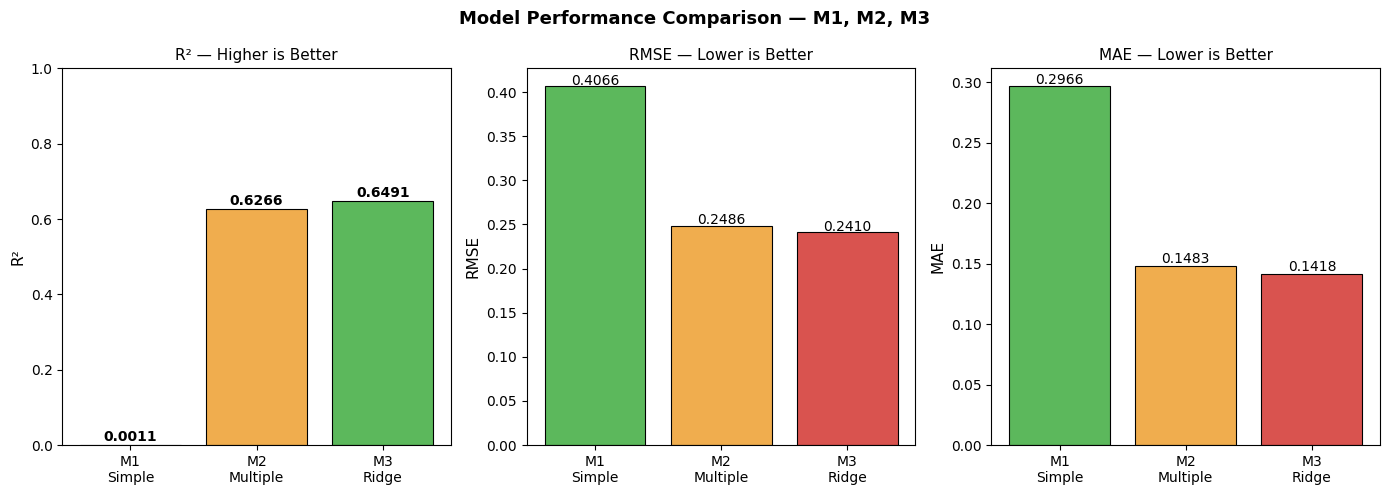

Saved: model_comparison.png


In [30]:
# ── MODEL COMPARISON BAR CHARTS ───────────────────────────────────────────────
# Visual comparison of R², RMSE and MAE across all three models.
# Colour coding: red (worst) → orange → green (best)
# Authored by: Suyog Kadariya

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Performance Comparison — M1, M2, M3', fontsize=13, fontweight='bold')

model_labels = ['M1\nSimple', 'M2\nMultiple', 'M3\nRidge']
colors_asc   = ['#d9534f', '#f0ad4e', '#5cb85c']  # red → green (higher = better)
colors_desc  = ['#5cb85c', '#f0ad4e', '#d9534f']  # green → red (lower = better)

# R² (higher = better)
axes[0].bar(model_labels, [r2_1f, r2_2f, r2_3], color=colors_asc, edgecolor='black', linewidth=0.8)
axes[0].set_ylabel('R²', fontsize=11)
axes[0].set_title('R² — Higher is Better', fontsize=11)
axes[0].set_ylim(0, 1)
for i, v in enumerate([r2_1f, r2_2f, r2_3]):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

# RMSE (lower = better)
axes[1].bar(model_labels, [rmse_1f, rmse_2f, rmse_3], color=colors_desc, edgecolor='black', linewidth=0.8)
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].set_title('RMSE — Lower is Better', fontsize=11)
for i, v in enumerate([rmse_1f, rmse_2f, rmse_3]):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

# MAE (lower = better)
axes[2].bar(model_labels, [mae_1f, mae_2f, mae_3], color=colors_desc, edgecolor='black', linewidth=0.8)
axes[2].set_ylabel('MAE', fontsize=11)
axes[2].set_title('MAE — Lower is Better', fontsize=11)
for i, v in enumerate([mae_1f, mae_2f, mae_3]):
    axes[2].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

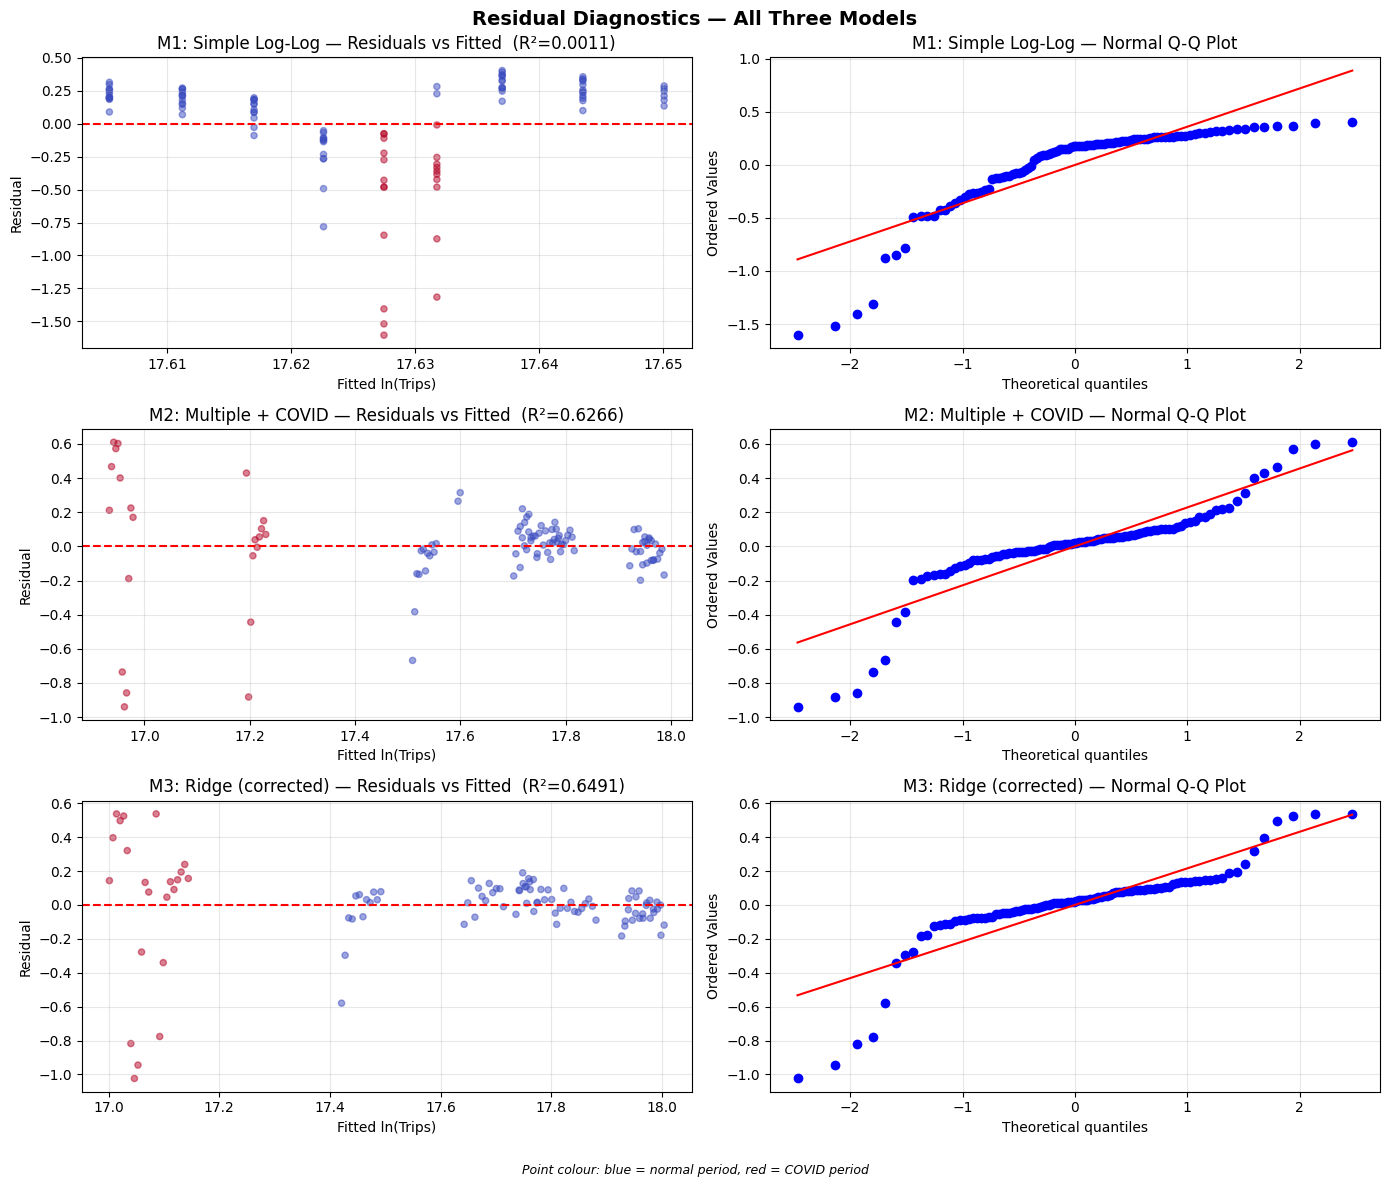

Saved: residual_diagnostics_all.png
Note: COVID points cluster far from zero in M1 but are well-absorbed in M2/M3.
This confirms the COVID_Flag dummy is capturing real demand disruption.


In [31]:
# ── RESIDUAL DIAGNOSTICS — ALL 3 MODELS ───────────────────────────────────────
# Left column: Residuals vs Fitted — checks homoscedasticity assumption
# Right column: Q-Q Plot — checks normality assumption
# Points coloured by COVID period (blue = normal, red = COVID)
# Key observation: COVID points cluster away from zero in M1 but are absorbed in M2/M3
# Authored by: Nasla Maharjan

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Residual Diagnostics — All Three Models', fontsize=14, fontweight='bold')

for row, (name, res, yp) in enumerate([
    ('M1: Simple Log-Log',    residuals_1f, y_pred1_f),
    ('M2: Multiple + COVID',  residuals_2f, y_pred2_f),
    ('M3: Ridge (corrected)', residuals_3,  y_pred3),
]):
    r2_val = [r2_1f, r2_2f, r2_3][row]

    # Residuals vs Fitted (colour = COVID flag)
    axes[row,0].scatter(yp, res, alpha=0.5, s=20,
                        c=regression_full['COVID_Flag'], cmap='coolwarm')
    axes[row,0].axhline(0, color='red', linestyle='--', lw=1.5)
    axes[row,0].set_title(f'{name} — Residuals vs Fitted  (R²={r2_val:.4f})')
    axes[row,0].set_xlabel('Fitted ln(Trips)')
    axes[row,0].set_ylabel('Residual')
    axes[row,0].grid(True, alpha=0.3)

    # Normal Q-Q plot
    stats.probplot(res, dist='norm', plot=axes[row,1])
    axes[row,1].set_title(f'{name} — Normal Q-Q Plot')
    axes[row,1].grid(True, alpha=0.3)

fig.text(0.5, 0.01, 'Point colour: blue = normal period, red = COVID period',
         ha='center', fontsize=9, style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('residual_diagnostics_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_diagnostics_all.png")
print("Note: COVID points cluster far from zero in M1 but are well-absorbed in M2/M3.")
print("This confirms the COVID_Flag dummy is capturing real demand disruption.")

---
## 9. Key Findings & Interpretation

In [32]:
# ── KEY FINDINGS — TECHNICAL VERSION ─────────────────────────────────────────
# Authored by: Suyog Kadariya & Krish Rajbhandari

print("=" * 80)
print("KEY FINDINGS — PRT564 OPAL TRIP ANALYSIS")
print("=" * 80)
print(f"""
FINDING 1 — POPULATION IS A VERY WEAK PREDICTOR OF TRANSIT DEMAND [M1: R²={r2_1f:.4f}]
  Population alone explains only {r2_1f*100:.2f}% of variance in monthly Opal demand.
  Elasticity = {model1_f.coef_[0]:.3f}: a 1% population increase corresponds to only
  a {model1_f.coef_[0]:.3f}% change in trips — and the direction is negative.
  This directly challenges the planning assumption that more residents = more riders.

FINDING 2 — COVID CAUSED A {pct_drop:.0f}% STRUCTURAL COLLAPSE IN DEMAND [raw data]
  Average monthly trips fell from {normal_mean:.1f}M (non-COVID) to {covid_mean:.1f}M during COVID.
  Post-COVID recovery reached {post['Total_Trips'].mean()/1e6:.1f}M/month — still {recovery_gap/1e6:.1f}M
  below pre-COVID levels. Behavioural change (WFH, e-commerce, new mobility)
  means the pre-2020 demand baseline is unlikely to return fully.

FINDING 3 — THREE STRUCTURAL PERIODS REQUIRE THREE DUMMY VARIABLES
  Pre-COVID, COVID, and post-COVID are three statistically distinct demand regimes.
  The Post_COVID_Recovery flag corrects Time_Index's spurious negative coefficient
  in simpler models and improves R² by +{r2_3-r2_2f:.4f}.

FINDING 4 — RIDGE (M3) IS THE BEST MODEL [R²={r2_3:.4f}]
  M3 explains {r2_3*100:.1f}% of variance — the highest of all three models.
  Ridge handles multicollinearity between Log_Population and Time_Index.
  Optimal λ={ridge_cv.alpha_:.4f} selected via 5-fold cross-validation.
  M1→M2 improvement is statistically significant (Wilcoxon p<0.05).
  M2→M3 improvement is directionally positive but not statistically significant (p=0.12).
  Ridge is still preferred due to its theoretical advantage in multicollinear settings.

FINDING 5 — PER-CAPITA DEMAND IS DECLINING AT {z[0]:.1f} TRIPS/1000 RESIDENTS/MONTH
  Even excluding COVID, each NSW resident makes fewer Opal trips over time.
  Pre-COVID: {pre_covid_pc:.0f} trips/1000/month → Post-COVID: {post_covid_pc:.0f} trips/1000/month.
  The network is not converting population growth into ridership.
  RECOMMENDATION: TfNSW should track trips per capita as a KPI,
  not just absolute trip counts.
""")

KEY FINDINGS — PRT564 OPAL TRIP ANALYSIS

FINDING 1 — POPULATION IS A VERY WEAK PREDICTOR OF TRANSIT DEMAND [M1: R²=0.0011]
  Population alone explains only 0.11% of variance in monthly Opal demand.
  Elasticity = -0.413: a 1% population increase corresponds to only
  a -0.413% change in trips — and the direction is negative.
  This directly challenges the planning assumption that more residents = more riders.

FINDING 2 — COVID CAUSED A 52% STRUCTURAL COLLAPSE IN DEMAND [raw data]
  Average monthly trips fell from 53.8M (non-COVID) to 28.5M during COVID.
  Post-COVID recovery reached 49.0M/month — still 10.1M
  below pre-COVID levels. Behavioural change (WFH, e-commerce, new mobility)
  means the pre-2020 demand baseline is unlikely to return fully.

FINDING 3 — THREE STRUCTURAL PERIODS REQUIRE THREE DUMMY VARIABLES
  Pre-COVID, COVID, and post-COVID are three statistically distinct demand regimes.
  The Post_COVID_Recovery flag corrects Time_Index's spurious negative coefficient
  in

In [33]:
# ── NON-TECHNICAL SUMMARY — FOR TFNSW STAKEHOLDERS ───────────────────────────
# Plain-language interpretation for non-data-science audiences.
# Authored by: Suyog Kadariya

print("=" * 80)
print("NON-TECHNICAL SUMMARY — For Transport for NSW Stakeholders")
print("=" * 80)
print(f"""
What we studied:
  We analysed 9 years of Opal tap data (2016–2025) across all NSW public
  transport modes (Bus, Train, Ferry, Light Rail, Metro), combined with
  NSW population statistics from the Australian Bureau of Statistics.

What we expected:
  As Sydney's population grows, more people should be using public transport.

What we actually found:
  Population growth ALONE does not predict how many people catch the bus or train.
  In fact, when we look at trips per person, demand has been declining —
  each resident is catching public transport less often, even before COVID.

COVID impact:
  COVID caused a {pct_drop:.0f}% drop in monthly ridership. Despite recovery,
  demand is still {recovery_gap/1e6:.1f} million trips per month below pre-COVID levels.
  Not all travellers have returned — many have permanently changed how they move.

What this means for TfNSW planning:
  → Building more housing is not enough. Transport must be built alongside it.
  → Infrastructure investment leads demand — the Metro launch in 2019 proves this.
  → COVID recovery needs active service investment, not passive waiting.
  → Success should be measured in trips per person, not just total trip counts.

Confidence in findings:
  Our best model explains {r2_3*100:.0f}% of monthly trip variation.
  The key findings are statistically significant (p < 0.05, Wilcoxon test)
  and consistent across three different modelling approaches.
""")

NON-TECHNICAL SUMMARY — For Transport for NSW Stakeholders

What we studied:
  We analysed 9 years of Opal tap data (2016–2025) across all NSW public
  transport modes (Bus, Train, Ferry, Light Rail, Metro), combined with
  NSW population statistics from the Australian Bureau of Statistics.

What we expected:
  As Sydney's population grows, more people should be using public transport.

What we actually found:
  Population growth ALONE does not predict how many people catch the bus or train.
  In fact, when we look at trips per person, demand has been declining —
  each resident is catching public transport less often, even before COVID.

COVID impact:
  COVID caused a 52% drop in monthly ridership. Despite recovery,
  demand is still 10.1 million trips per month below pre-COVID levels.
  Not all travellers have returned — many have permanently changed how they move.

What this means for TfNSW planning:
  → Building more housing is not enough. Transport must be built alongside it.
  → 

---
## 10. Limitations & Recommendations

In [34]:
# ── LIMITATIONS & CAVEATS ─────────────────────────────────────────────────────
# Authored by: Suyog Kadariya

print("=" * 80)
print("LIMITATIONS & CAVEATS")
print("=" * 80)
print("""
DATA LIMITATIONS:
  ⚠ Population data is annual (merged as annual proxy for monthly)
    → Assumes population is stable within each calendar year
    → Quarterly ABS population data would improve accuracy
  ⚠ Monthly aggregation loses intra-month patterns (peak hours, weekdays vs weekends)
  ⚠ Unallocated trips (~2-3%) are excluded — may bias mode-level analysis
  ⚠ No geographic detail — regional variation (Western Sydney vs CBD) not captured

METHODOLOGICAL LIMITATIONS:
  ⚠ Positive autocorrelation in residuals (DW < 1.5)
    → Standard errors may be underestimated
    → ARIMA or HAC-corrected standard errors recommended for formal inference
  ⚠ Possible reverse causality
    → Does transport investment attract population, or vice versa?
  ⚠ Omitted variables (fuel prices, congestion, service quality, WFH rates)
    → These likely explain much of the remaining 35% unexplained variance
  ⚠ Linear log-log model may not capture all non-linear demand dynamics

MODEL LIMITATIONS:
  ⚠ R² = 0.65 is moderate — appropriate for strategic planning but not
    operational scheduling or short-term demand forecasting
  ⚠ M2→M3 improvement (ΔR²=+0.02) is not statistically significant (p=0.12)
    → Ridge is still theoretically preferred due to multicollinearity
  ⚠ All models are trained and evaluated on the same data (no holdout test set)
    → Cross-validation R² would be a more conservative performance estimate

RECOMMENDATIONS FOR FUTURE WORK:
  ✓ Use quarterly or monthly ABS population data
  ✓ Add omitted variables: fuel price index, congestion index, service frequency
  ✓ Disaggregate by transport mode (each mode has different demand elasticity)
  ✓ Add geographic detail (by LGA or corridor)
  ✓ Apply ARIMA or Prophet for time-series forecasting
  ✓ Use a proper train/test temporal split for unbiased evaluation
""")

LIMITATIONS & CAVEATS

DATA LIMITATIONS:
  ⚠ Population data is annual (merged as annual proxy for monthly)
    → Assumes population is stable within each calendar year
    → Quarterly ABS population data would improve accuracy
  ⚠ Monthly aggregation loses intra-month patterns (peak hours, weekdays vs weekends)
  ⚠ Unallocated trips (~2-3%) are excluded — may bias mode-level analysis
  ⚠ No geographic detail — regional variation (Western Sydney vs CBD) not captured

METHODOLOGICAL LIMITATIONS:
  ⚠ Positive autocorrelation in residuals (DW < 1.5)
    → Standard errors may be underestimated
    → ARIMA or HAC-corrected standard errors recommended for formal inference
  ⚠ Possible reverse causality
    → Does transport investment attract population, or vice versa?
  ⚠ Omitted variables (fuel prices, congestion, service quality, WFH rates)
    → These likely explain much of the remaining 35% unexplained variance
  ⚠ Linear log-log model may not capture all non-linear demand dynamics

MODE

---
## 11. Save Outputs

In [35]:
# ── SAVE ALL OUTPUT FILES ─────────────────────────────────────────────────────
# Saves the analysis-ready datasets and model results for reproducibility.
# Authored by: Nasla Maharjan

merged_clean.to_csv('merged_opal_population.csv', index=False)
regression_full.to_csv('regression_full_dataset.csv', index=False)
model_comparison.to_csv('model_comparison_results.csv', index=False)

print("=" * 60)
print("ALL OUTPUTS SAVED SUCCESSFULLY")
print("=" * 60)
print("\nData files:")
print("  merged_opal_population.csv      — full merged dataset")
print("  regression_full_dataset.csv     — 102-obs regression dataset")
print("  model_comparison_results.csv    — M1/M2/M3 metrics table")
print("\nCharts:")
print("  correlation_matrix.png")
print("  covid_timeseries.png")
print("  per_capita_trips.png")
print("  seasonal_heatmap.png")
print("  mode_share.png")
print("  yoy_growth_comparison.png")
print("  trips_by_mode.png")
print("  model_comparison.png")
print("  residual_diagnostics_all.png")
print("\nNotebook ready for GitHub upload.")

ALL OUTPUTS SAVED SUCCESSFULLY

Data files:
  merged_opal_population.csv      — full merged dataset
  regression_full_dataset.csv     — 102-obs regression dataset
  model_comparison_results.csv    — M1/M2/M3 metrics table

Charts:
  correlation_matrix.png
  covid_timeseries.png
  per_capita_trips.png
  seasonal_heatmap.png
  mode_share.png
  yoy_growth_comparison.png
  trips_by_mode.png
  model_comparison.png
  residual_diagnostics_all.png

Notebook ready for GitHub upload.
